In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
import os
import re

# for bessel functions and curve fitting
from scipy.optimize import curve_fit
from scipy import special

# plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amssymb}"
})

In [3]:
def sci_notation_latex(x, precision=2):
    mantissa, exp = f"{x:.{precision}e}".split("e")
    return rf"{mantissa} \cdot 10^{{{int(exp)}}}"

In [4]:
def get_lin_fit(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    y_fit = slope * x + intercept
    r_squared = 1- np.sum((y - y_fit)**2)/(np.sum((y - np.mean(y))**2)) # R^2 = 1 - SS_res / SS_tot = 1 - (y-y_fit)^2/(y-mean(y))^2

    return slope, intercept, r_squared

def get_R_from_lin_fit(list_of_measurements):
    R_list = []
    for key in list_of_measurements.keys():
        slope, intercept, r_squared = get_lin_fit(list_of_measurements[key]['delta_V'], list_of_measurements[key]['Iin'])
        R_list.append((1/slope))  # in ohm
    return R_list

In [15]:
def plot_IV_curves(list_of_measurements, folder_path):
    colors = plt.get_cmap("viridis", len(list_of_measurements))
    plt.figure(figsize=(8, 5))

    for i, key in enumerate(list_of_measurements.keys()):
        plt.plot(list_of_measurements[key]['delta_V'], list_of_measurements[key]['Iin']*1000, 'o-', color=colors(i), label=f"{key} $\\mu m$")

    plt.xlabel("Voltage / V")
    plt.ylabel("Current / mA")
    # plt.xlim(-0.5, 0.5)
    plt.title(os.path.basename(folder_path))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'IV_plot.pdf'), dpi=300)
    plt.savefig(os.path.join(folder_path, 'IV_plot.png'), dpi=300)
    plt.show()

In [6]:
# @param geometries: arrays with the ditances and inner radius of the CTLM structure
# @param Rsh: sheet resistance -> initial guess
# @param Lt: transfer length -> initial guess
# this still uses the assumption of R_sh being constant under and between the contacts
def ctlm_bessel_model(geometries, Rsh, L_T):
        
        (distances, r_inner) = geometries
        # Term 1: Resistance of the semiconductor gap
        term_gap = np.log((r_inner + distances) / r_inner)
        
        # Term 2: Resistance of the inner contact (using using bessel functions I0 and I1)
        term_inner = (L_T / r_inner) * (special.i0(r_inner / L_T) / special.i1(r_inner / L_T))
        
        # Term 3: Resistance of the outer contact (using bessel functions K0 and K1)
        term_outer = (L_T / (r_inner + distances)) * (special.k0((r_inner + distances) / L_T) / special.k1((r_inner + distances) / L_T))
        
        # Total Resistance
        R_T = (Rsh / (2 * np.pi)) * (term_gap + term_inner + term_outer)

        return R_T

def plot_ctlm_fit(distances, R_list, r_inner, folder_path):
    # Initial Guess: [Rsh, Lt]
    # p0 = [R_sh_linear, L_T_linear]
    p0 = [1, 100]
    # p0 = [1, 1]
    bounds = ([0, 0], [np.inf, np.inf])
    r_inner_array = np.full_like(distances, r_inner)

    popt, pcov = curve_fit(ctlm_bessel_model, (distances, r_inner_array), R_list, p0=p0, bounds=bounds)

    Rsh_fit, Lt_fit = popt

    rho_c_fit = Rsh_fit * (Lt_fit**2) * 1e-8  # 1e-8 to convert from ohm·μm² to ohm·cm²

    distances_smooth = np.linspace(0, max(distances), 300) # min(distances)
    ri_smooth = np.full_like(distances_smooth, r_inner)
    Rt_fit_curve = ctlm_bessel_model((distances_smooth, ri_smooth), Rsh_fit, Lt_fit)

    plt.figure()
    plt.scatter(distances, R_list, color='orange', marker='o', label='Measured Resistance')
    plt.plot(distances_smooth, Rt_fit_curve, color='blue', linestyle='--', label='Bessel Function Fit')

    tlm_text = (
        f"$R_{{sh}} = {Rsh_fit:.2f} \\, \\Omega / \\square$\n"
        f"$L_T = {Lt_fit:.2f} \\, \\mu m$\n"
        f"$\\rho_C = {sci_notation_latex(rho_c_fit)} \\, \\Omega cm^2$"
    )

    plt.gca().text(
        0.95, 0.1, tlm_text,
        fontsize=9,
        transform=plt.gca().transAxes,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    plt.axhline(0, color='black', linewidth=1.5)
    plt.axvline(0, color='black', linewidth=1.5)

    plt.title(os.path.basename(folder_path))
    plt.xlabel("Contact Spacing / $\\mu m$")
    plt.ylabel("Total Resistance / $\\Omega$")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.xlim(0, max(list_of_measurements.keys())+20)
    plt.savefig(os.path.join(folder_path, 'cTLM_plot.pdf'), dpi=300)
    plt.savefig(os.path.join(folder_path, 'cTLM_plot.png'), dpi=300)
    plt.show()

    return [Rsh_fit, Lt_fit, rho_c_fit]

Processing folder: ../Data/IV/cTLM_final_NiGe_900\[processname=cTLM_Ni][structure=CTLM][ri=150][description=Mitte]


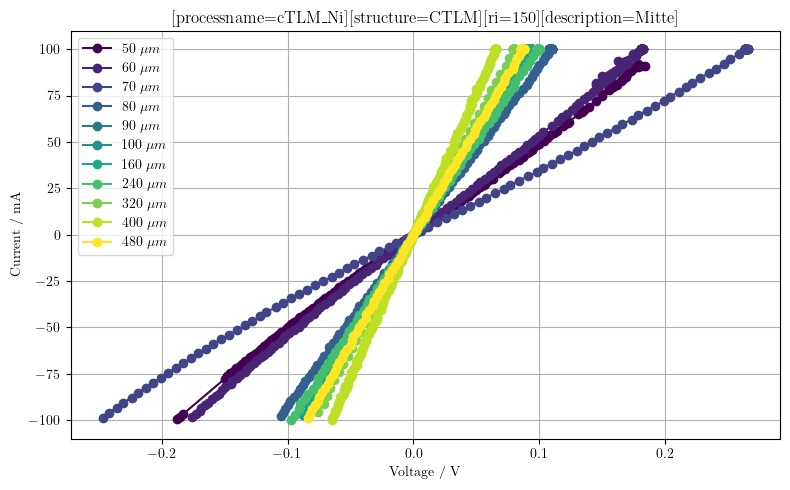

[np.float64(1.9808152112209185), np.float64(1.8252764862798763), np.float64(2.6506382034549594), np.float64(1.0893360183509992), np.float64(0.8891790484184775), np.float64(0.9240264610013703), np.float64(0.9053332767351482), np.float64(0.9860386158658258), np.float64(0.7992735127597044), np.float64(0.6552564382811731), np.float64(0.8651307769982567)]
Processing folder: ../Data/IV/cTLM_final_NiGe_900\[processname=cTLM_Ni][structure=CTLM][ri=150][description=Norden]


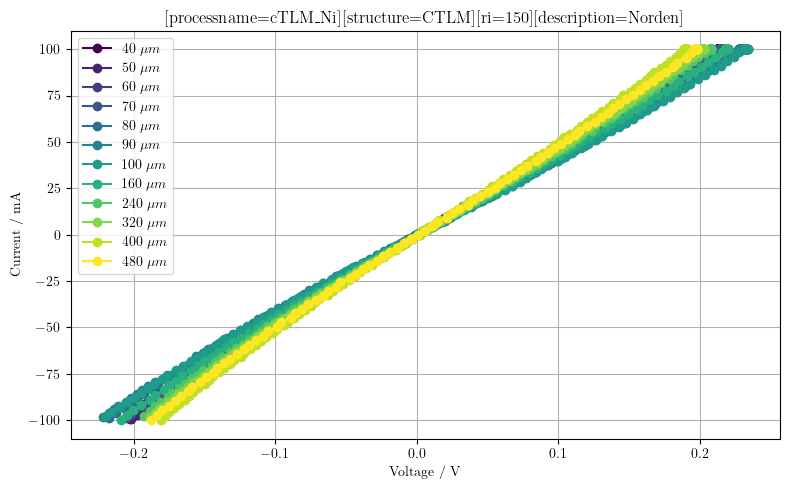

[np.float64(2.1339404888735483), np.float64(2.08607293831475), np.float64(2.166455201758363), np.float64(2.1649388905889917), np.float64(2.2972627878451846), np.float64(2.319282277929849), np.float64(2.338435023988512), np.float64(2.1919635390821726), np.float64(2.074949481866603), np.float64(2.019729295921939), np.float64(1.8994448854950985), np.float64(1.96972271973781)]
Processing folder: ../Data/IV/cTLM_final_NiGe_900\[processname=cTLM_Ni][structure=CTLM][ri=150][description=Süden-Mitte]


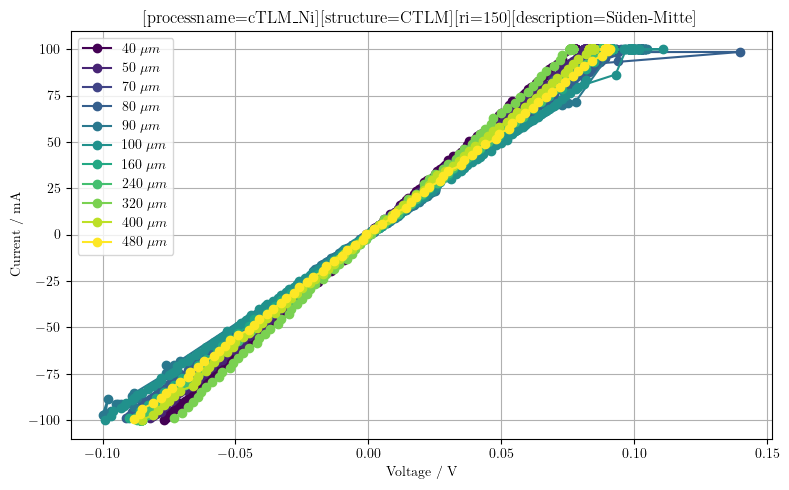

[np.float64(0.7730024788608433), np.float64(0.8252807344718636), np.float64(0.8644700034453298), np.float64(0.9379849617924402), np.float64(1.0240714427053978), np.float64(0.9967997522173727), np.float64(0.9095697736994267), np.float64(0.8710902742018012), np.float64(0.751551607156988), np.float64(0.8411762798068901), np.float64(0.8976727845881687)]


In [21]:
from readTLMData import TLMREADER
parent_folder = r"../Data/IV/cTLM_final_NiGe_900"

for folder in os.listdir(parent_folder):
    folder_path = os.path.join(parent_folder, folder)
    if os.path.isdir(folder_path):
        print(f"Processing folder: {folder_path}")

        try:
            list_of_measurements = TLMREADER(folder_path).readTLMData()
            list_of_measurements = dict(sorted(list_of_measurements.items()))

            r_inner = TLMREADER(folder_path).get_r_inner()
            distances = list(map(int, list_of_measurements.keys()))

            R_list = get_R_from_lin_fit(list_of_measurements)
            plot_IV_curves(list_of_measurements, folder_path)
            print(R_list)

            fit_params = plot_ctlm_fit(distances, R_list, r_inner, folder_path)
        except:
            pass